In [1]:
# train_model_clustering.py
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 1. LOAD DATA
print("\n[1/7] Membaca data...")
data = pd.read_csv('student-por.csv', sep=';')
print(f"   Total data: {len(data)} siswa")


[1/7] Membaca data...
   Total data: 649 siswa


In [3]:
# 2. PILIH FITUR UNTUK CLUSTERING
print("\n[2/7] Memilih fitur untuk segmentasi...")

fitur_clustering = [
    # Nilai akademik
    'G1',           # Nilai periode 1
    'G2',           # Nilai periode 2
    'G3',           # Nilai akhir
    
    # Kebiasaan belajar
    'studytime',    # Waktu belajar
    'failures',     # Jumlah gagal
    'absences',     # Absensi
    
    # Aktivitas sosial
    'goout',        # Hangout dengan teman
    'freetime',     # Waktu luang
    'Dalc',         # Alkohol hari kerja
    'Walc',         # Alkohol akhir pekan
    
    # Faktor personal
    'famrel',       # Hubungan keluarga
    'health'        # Kesehatan
]

# Gunakan fitur yang tersedia
X = data[fitur_clustering].copy()

print(f"   Fitur yang digunakan: {len(fitur_clustering)} fitur")
for i, f in enumerate(fitur_clustering, 1):
    print(f"      {i}. {f}")


[2/7] Memilih fitur untuk segmentasi...
   Fitur yang digunakan: 12 fitur
      1. G1
      2. G2
      3. G3
      4. studytime
      5. failures
      6. absences
      7. goout
      8. freetime
      9. Dalc
      10. Walc
      11. famrel
      12. health


In [4]:
# 3. NORMALISASI DATA
print("\n[3/7] Normalisasi data...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"   Data berhasil dinormalisasi (mean=0, std=1)")


[3/7] Normalisasi data...
   Data berhasil dinormalisasi (mean=0, std=1)



[4/7] Mencari jumlah cluster optimal...
   Grafik elbow method disimpan: elbow_method.png

   Jumlah cluster yang dipilih: 4
      (Berdasarkan elbow point dan silhouette score)


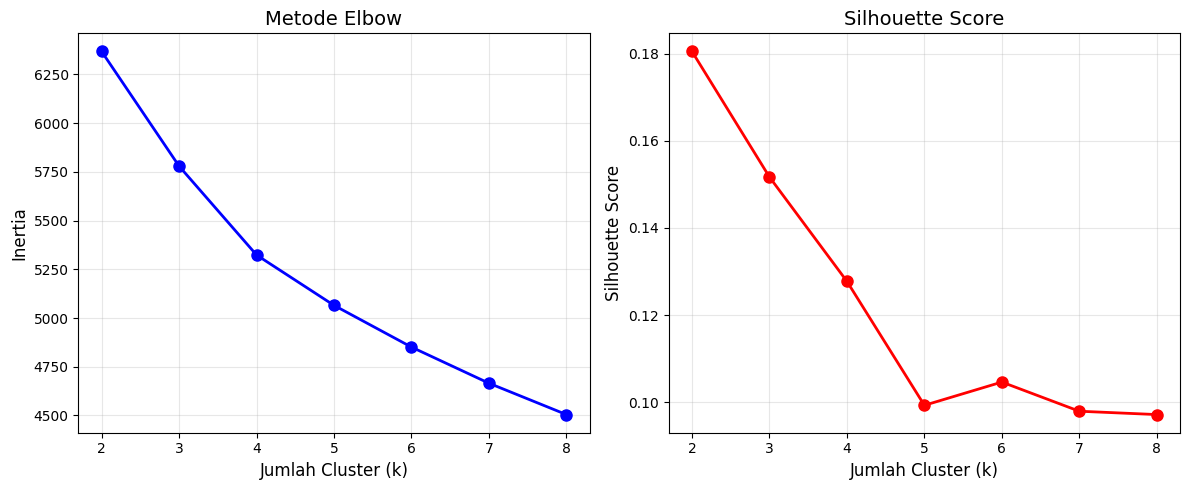

In [5]:
# 4. TENTUKAN JUMLAH CLUSTER OPTIMAL
print("\n[4/7] Mencari jumlah cluster optimal...")

# Metode Elbow (Inertia)
inertias = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow Method
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Jumlah Cluster (k)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('Metode Elbow', fontsize=14)
ax1.grid(True, alpha=0.3)

ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Jumlah Cluster (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_method.png', dpi=100)
print("   Grafik elbow method disimpan: elbow_method.png")

# Pilih jumlah cluster (4)
n_clusters = 4
print(f"\n   Jumlah cluster yang dipilih: {n_clusters}")
print(f"      (Berdasarkan elbow point dan silhouette score)")

In [6]:
# 5. LATIH MODEL K-MEANS
print(f"\n[5/7] Melatih K-Means dengan {n_clusters} cluster...")

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
data['cluster'] = kmeans.fit_predict(X_scaled)

print(f"   Model selesai dilatih!")


[5/7] Melatih K-Means dengan 4 cluster...
   Model selesai dilatih!


In [7]:
# 6. ANALISIS SETIAP CLUSTER
print("\n[6/7] Analisis karakteristik setiap cluster...")

# Statistik per cluster
cluster_counts = data['cluster'].value_counts().sort_index()

# Urutkan cluster berdasarkan G3 (nilai tertinggi ke terendah)
cluster_order = data.groupby('cluster')['G3'].mean().sort_values(ascending=False).index.tolist()

# Beri nama segment
segment_names = {
    cluster_order[0]: "SANGAT BAIK (Prestasi Tinggi)",
    cluster_order[1]: "BAIK (Potensi Bagus)",
    cluster_order[2]: "CUKUP (Perlu Motivasi)",
    cluster_order[3]: "KURANG (Butuh Bimbingan)"
}

print("\n   HASIL SEGMENTASI:")
print("   " + "="*60)

for cluster in cluster_order:
    nama = segment_names[cluster]
    jumlah = cluster_counts[cluster]
    persen = jumlah/len(data)*100
    
    # Ambil statistik
    mean_g3 = data[data['cluster'] == cluster]['G3'].mean()
    mean_studytime = data[data['cluster'] == cluster]['studytime'].mean()
    mean_absences = data[data['cluster'] == cluster]['absences'].mean()
    mean_failures = data[data['cluster'] == cluster]['failures'].mean()
    mean_goout = data[data['cluster'] == cluster]['goout'].mean()
    
    print(f"\n   {nama}")
    print(f"   " + "-"*50)
    print(f"   Jumlah siswa: {jumlah} ({persen:.1f}%)")
    print(f"   Rata-rata G3: {mean_g3:.1f}")
    print(f"   Rata-rata belajar: {mean_studytime:.1f} (1-4)")
    print(f"   Rata-rata absensi: {mean_absences:.1f} kali")
    print(f"   Rata-rata gagal: {mean_failures:.1f} kali")
    print(f"   Rata-rata hangout: {mean_goout:.1f} (1-5)")

print("\n   " + "="*60)

# Hitung metrik clustering
silhouette_avg = silhouette_score(X_scaled, data['cluster'])
davies_bouldin = davies_bouldin_score(X_scaled, data['cluster'])

print(f"\n   METRIK CLUSTERING:")
print(f"   " + "-"*40)
print(f"   Silhouette Score: {silhouette_avg:.3f}")
print(f"   Davies-Bouldin Score: {davies_bouldin:.3f}")
print(f"   " + "-"*40)


[6/7] Analisis karakteristik setiap cluster...

   HASIL SEGMENTASI:

   SANGAT BAIK (Prestasi Tinggi)
   --------------------------------------------------
   Jumlah siswa: 224 (34.5%)
   Rata-rata G3: 14.9
   Rata-rata belajar: 2.4 (1-4)
   Rata-rata absensi: 2.2 kali
   Rata-rata gagal: 0.0 kali
   Rata-rata hangout: 3.2 (1-5)

   BAIK (Potensi Bagus)
   --------------------------------------------------
   Jumlah siswa: 235 (36.2%)
   Rata-rata G3: 11.1
   Rata-rata belajar: 1.8 (1-4)
   Rata-rata absensi: 3.7 kali
   Rata-rata gagal: 0.1 kali
   Rata-rata hangout: 2.7 (1-5)

   CUKUP (Perlu Motivasi)
   --------------------------------------------------
   Jumlah siswa: 128 (19.7%)
   Rata-rata G3: 10.7
   Rata-rata belajar: 1.6 (1-4)
   Rata-rata absensi: 6.1 kali
   Rata-rata gagal: 0.2 kali
   Rata-rata hangout: 4.1 (1-5)

   KURANG (Butuh Bimbingan)
   --------------------------------------------------
   Jumlah siswa: 62 (9.6%)
   Rata-rata G3: 6.9
   Rata-rata belajar: 1.5 


[7/7] Membuat visualisasi cluster...
   Visualisasi cluster disimpan: cluster_visualization.png


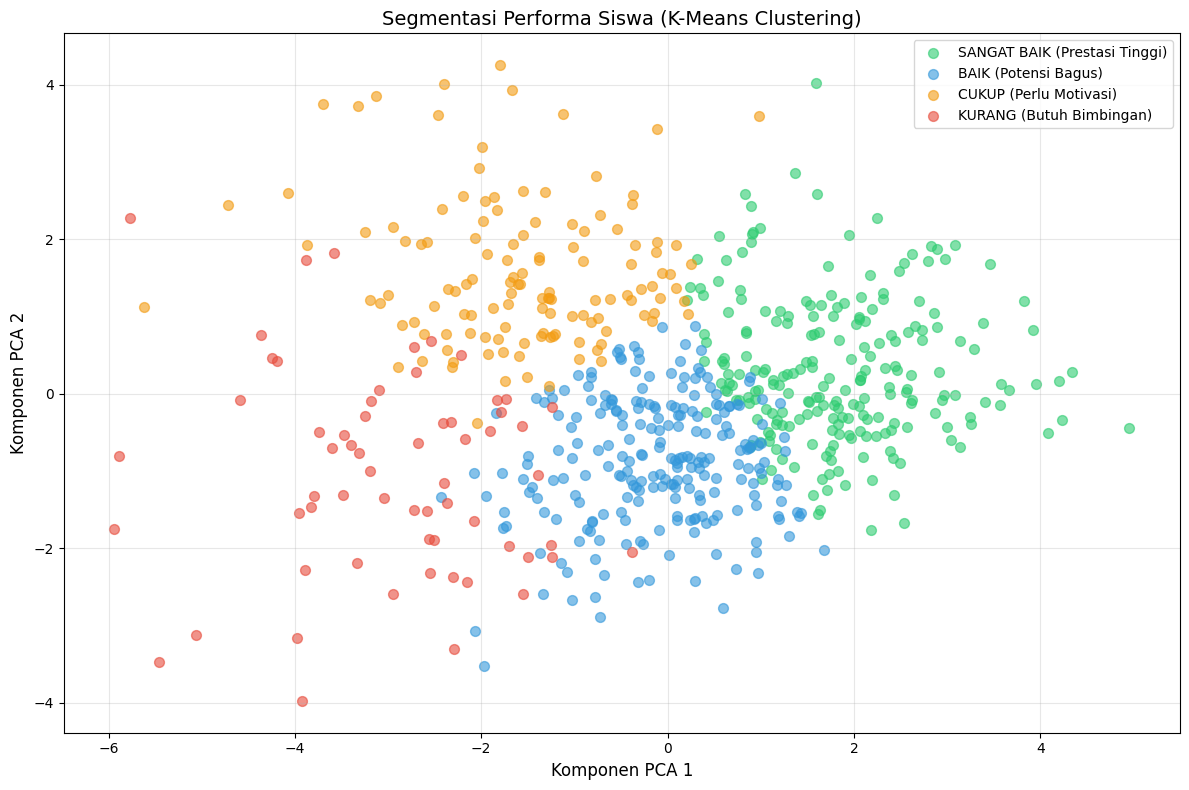

In [8]:
# 7. VISUALISASI CLUSTER
print("\n[7/7] Membuat visualisasi cluster...")

# PCA untuk reduksi dimensi (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Warna untuk setiap cluster
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']

plt.figure(figsize=(12, 8))

for i, cluster in enumerate(cluster_order):
    mask = data['cluster'] == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=colors[i], 
                label=segment_names[cluster],
                alpha=0.6, s=50)

plt.xlabel('Komponen PCA 1', fontsize=12)
plt.ylabel('Komponen PCA 2', fontsize=12)
plt.title('Segmentasi Performa Siswa (K-Means Clustering)', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cluster_visualization.png', dpi=150)
print("   Visualisasi cluster disimpan: cluster_visualization.png")

In [9]:
# 8. SIMPAN MODEL
print("\nMenyimpan model...")

# Buat folder jika belum ada
os.makedirs('clustering', exist_ok=True)

# Simpan model K-Means
joblib.dump(kmeans, 'clustering/model_clustering.pkl')
print("   clustering/model_clustering.pkl")

# Simpan scaler
joblib.dump(scaler, 'clustering/scaler_clustering.pkl')
print("   clustering/scaler_clustering.pkl")

# Simpan PCA
joblib.dump(pca, 'clustering/pca_clustering.pkl')
print("   clustering/pca_clustering.pkl")

# Simpan fitur yang digunakan
joblib.dump(fitur_clustering, 'clustering/fitur_clustering.pkl')
print("   clustering/fitur_clustering.pkl")

# Simpan nama segment
joblib.dump(segment_names, 'clustering/nama_segment.pkl')
print("   clustering/nama_segment.pkl")

# Simpan statistik cluster
cluster_statistics = {
    'jumlah_siswa': cluster_counts.to_dict(),
    'persentase': (cluster_counts/len(data)*100).to_dict(),
    'segment_names': segment_names,
    'cluster_order': cluster_order,
    'silhouette_score': float(silhouette_avg),
    'davies_bouldin_score': float(davies_bouldin)
}

import json
def convert_to_serializable(obj):
    if isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    return str(obj)

with open('clustering/statistik_cluster.json', 'w') as f:
    json.dump(cluster_statistics, f, indent=2, default=convert_to_serializable)
print("   clustering/statistik_cluster.json")

print("\n" + "="*70)
print(" " * 20 + "MODEL CLUSTERING SELESAI DISIMPAN!")
print("="*70)

print("\nStruktur folder:")
print("   clustering/")
print("   ├── model_clustering.pkl")
print("   ├── scaler_clustering.pkl")
print("   ├── pca_clustering.pkl")
print("   ├── fitur_clustering.pkl")
print("   ├── nama_segment.pkl")
print("   └── statistik_cluster.json")

print("\nRingkasan:")
print(f"   Jumlah cluster: {n_clusters}")
print(f"   Silhouette Score: {silhouette_avg:.3f}")
print(f"   Davies-Bouldin: {davies_bouldin:.3f}")


Menyimpan model...
   clustering/model_clustering.pkl
   clustering/scaler_clustering.pkl
   clustering/pca_clustering.pkl
   clustering/fitur_clustering.pkl
   clustering/nama_segment.pkl
   clustering/statistik_cluster.json

                    MODEL CLUSTERING SELESAI DISIMPAN!

Struktur folder:
   clustering/
   ├── model_clustering.pkl
   ├── scaler_clustering.pkl
   ├── pca_clustering.pkl
   ├── fitur_clustering.pkl
   ├── nama_segment.pkl
   └── statistik_cluster.json

Ringkasan:
   Jumlah cluster: 4
   Silhouette Score: 0.128
   Davies-Bouldin: 1.994
